In [1]:
from pathlib import Path
import numpy as np
import torch
from visualization.visualize_helper import *

work_dir = Path().cwd() 

fig_save_dir = work_dir / "visualization" / "sample_figures" / "acc_figures"
if not fig_save_dir.exists():
    Path.mkdir(fig_save_dir)

# Performance

In [2]:
exp_name = 'LQ-reftrack'
opt = -0.24542893

batch_sizes = ['64']
n_batches = 101
n_seeds = 105
seeds, batches = np.arange(n_seeds), np.arange(n_batches)

base_dir = work_dir.parents[0] / "logs" / exp_name
assert base_dir.exists()

In [3]:
# exlude seeds where any method encounters infeasible optimization
methods = ['REINFORCE/algo_REINFORCE_init_A_num_epi_batches_101_policy_type_CVXPY_task_LQ-reftrack',
           'BO/algo_BO_init_A_num_epi_batches_101_policy_type_CVXPY_task_LQ-reftrack',
           'REINFORCE/algo_REINFORCE_init_None_num_epi_batches_101_policy_type_CVXPY_task_LQ-reftrack',
           'BO/algo_BO_init_None_num_epi_batches_101_policy_type_CVXPY_task_LQ-reftrack']
           
valid_seeds = check_seed_validity(base_dir, methods, batch_sizes, n_seeds, n_batches)

In [4]:
# learning A & B (20 parameters)
methods = ['REINFORCE/algo_REINFORCE_init_None_num_epi_batches_101_policy_type_CVXPY_task_LQ-reftrack']

res = get_results(base_dir, methods, batch_sizes, batches, valid_seeds, n_batches)
# res_avgs, res_errs = mean_confidence_interval(res)
res_avgs, res_errs = np.mean(res, axis=-1), 2*np.std(res, axis=-1, ddof=1)

sorted_res = sort_results(res, methods, batch_sizes, valid_seeds)
sorted_reg = opt - sorted_res
sorted_avgs = np.mean(sorted_reg, axis=-1)
sorted_stds = np.std(sorted_reg, axis=-1)
# sorted_avgs, sorted_errs = mean_confidence_interval(sorted_reg)
sorted_avgs, sorted_errs = np.mean(sorted_reg, axis=-1), 2*np.std(sorted_reg, axis=-1, ddof=1)

# Model

In [5]:
A = 0.5 * np.array([
    [1., 0., 2., 0.],
    [0., 1., 0., 1.],
    [0., 0., 1., 2.],
    [1., 0., 0., 1.],
])
B = np.array([
    [0.5],
    [0.],
    [0.],
    [0.]
])

In [6]:
batches = np.arange(n_batches)
res_A, res_B = get_matrices(base_dir, methods, batch_sizes, batches, valid_seeds)
norm = "fro"
mean_frob_A, mean_frob_B, err_frob_A, err_frob_B = calc_norm(res_A, res_B, A, B, norm)

# New Plot

In [7]:
res_avgs = res_avgs[0,0]
res_errs = res_errs[0,0]
sorted_avgs = sorted_avgs[0,0]
sorted_errs = sorted_errs[0,0]
mean_frob_A = mean_frob_A[0,0]
mean_frob_B = mean_frob_B[0,0]
err_frob_A = err_frob_A[0,0]
err_frob_B = err_frob_B[0,0]

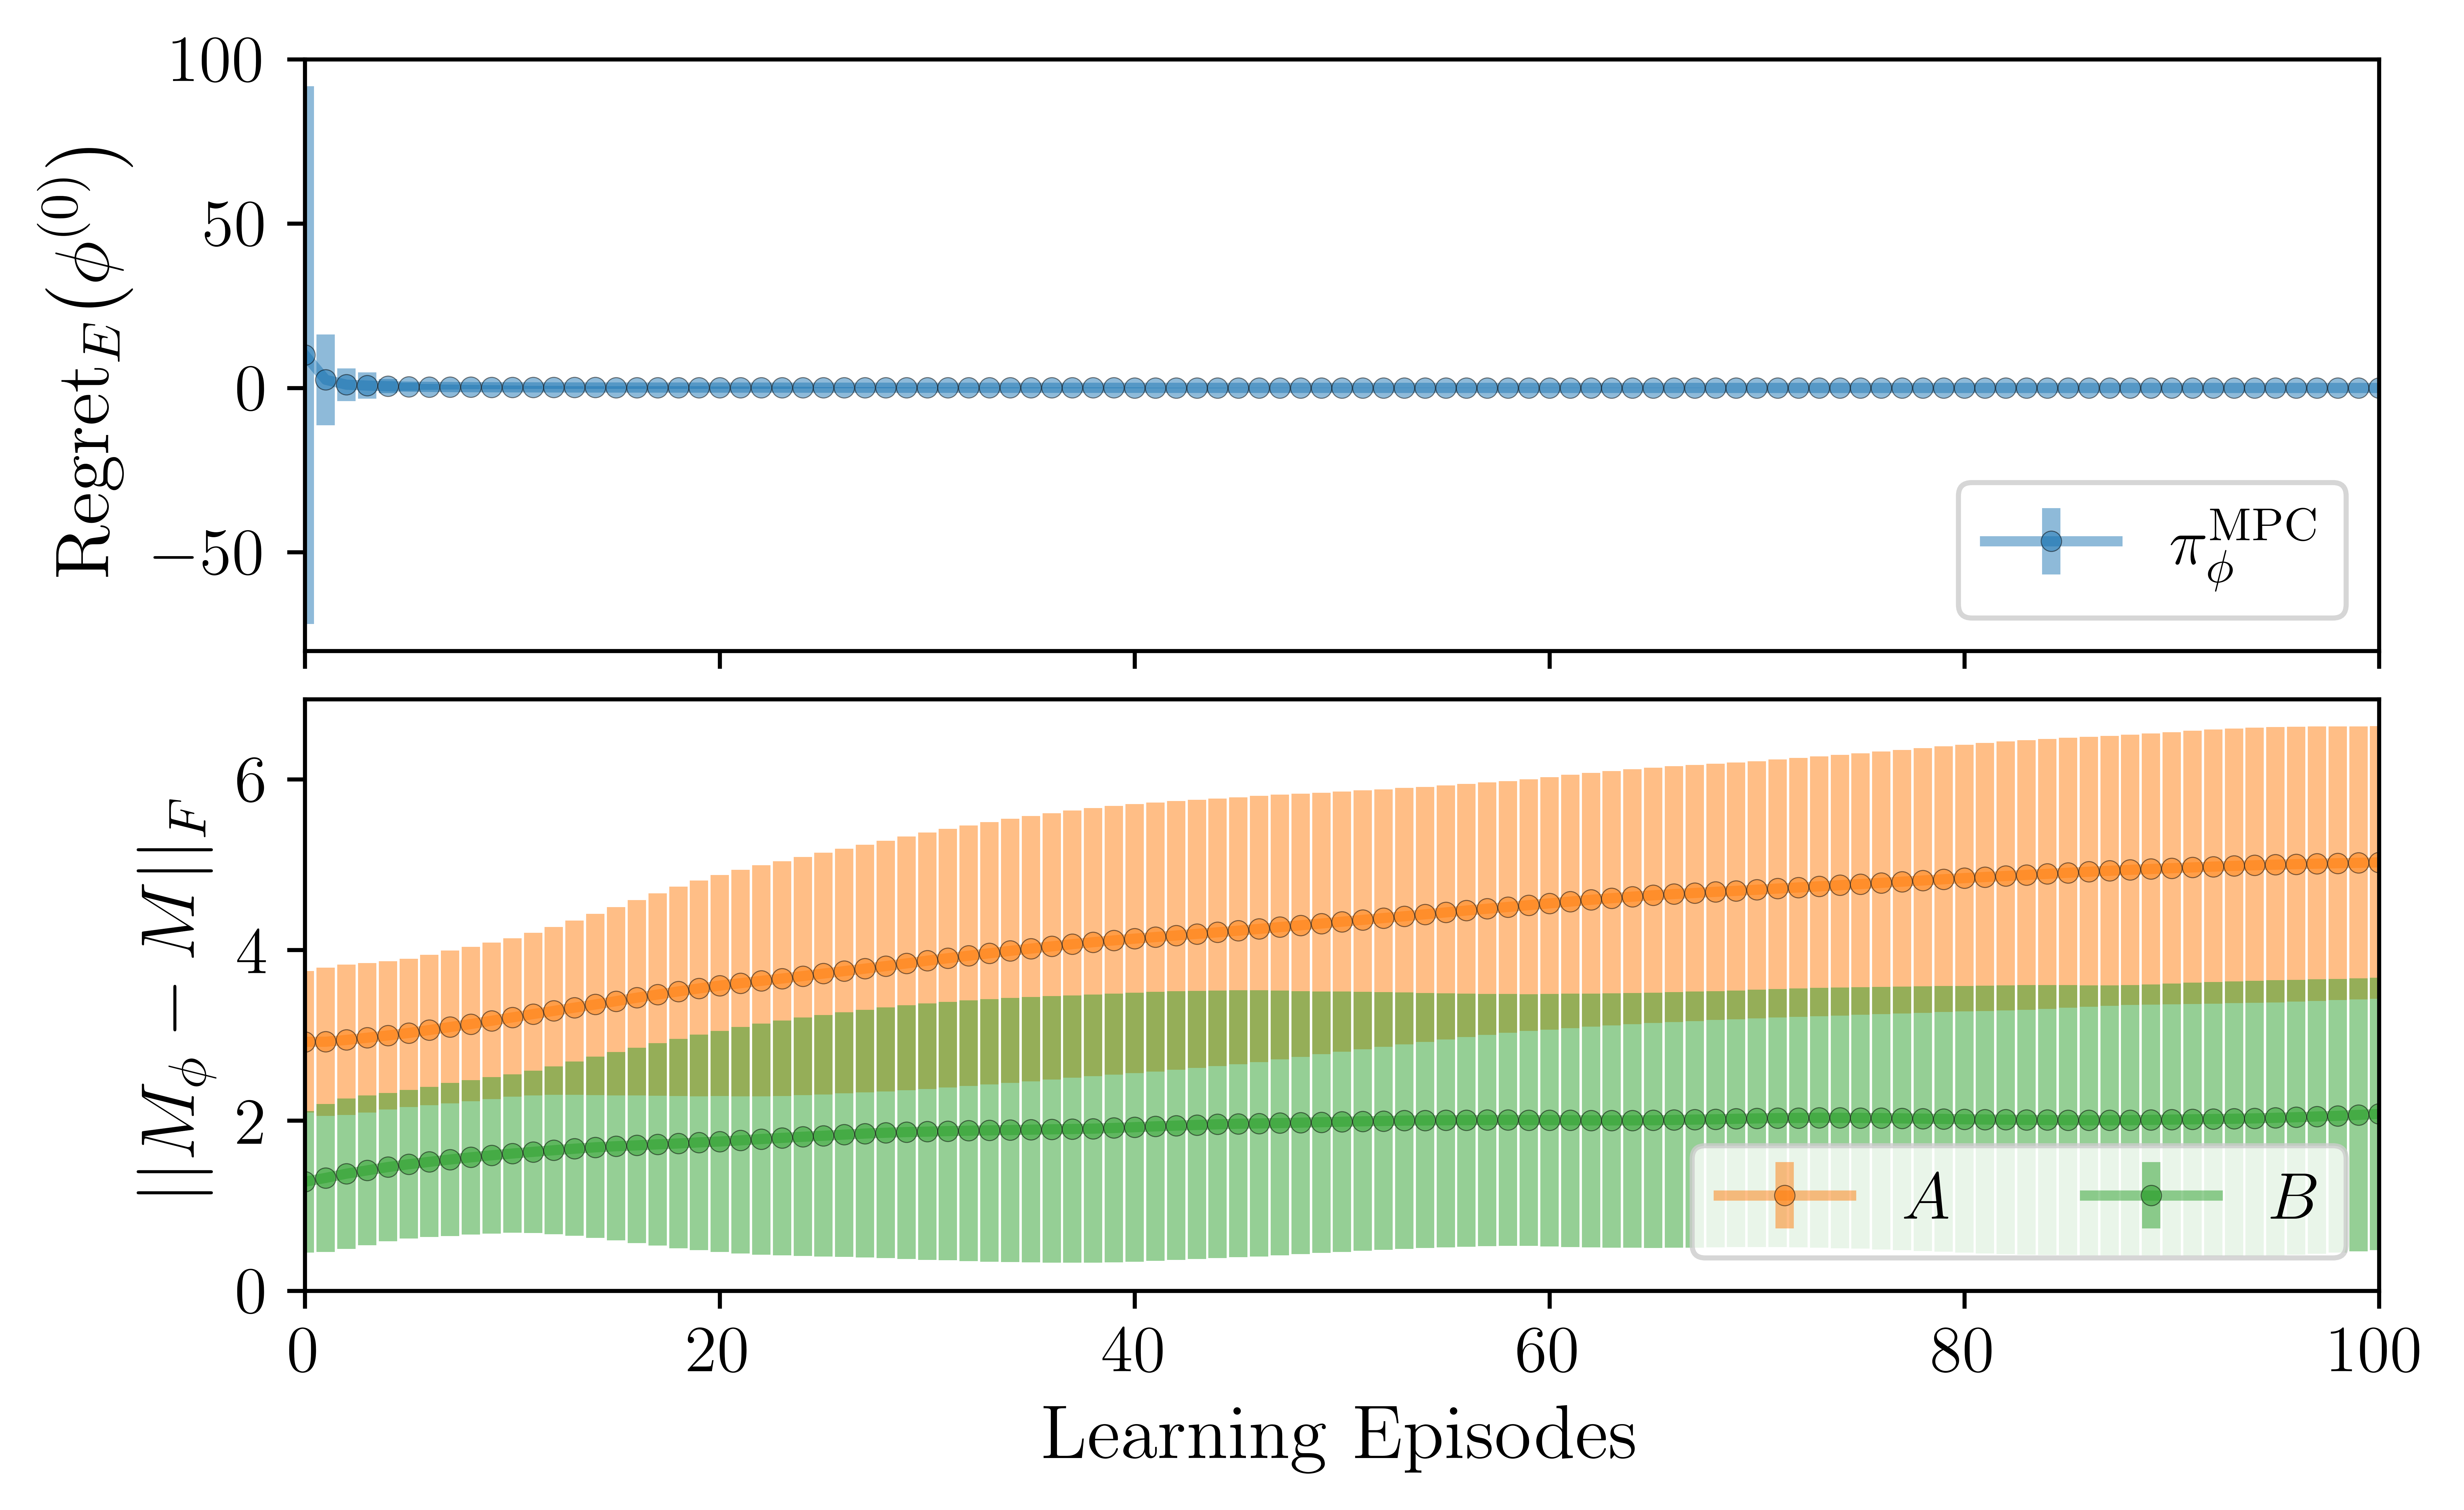

In [11]:
fn = fig_save_dir / 'LQ_regret-mismatch'
plot_reg_err(batches, sorted_avgs, sorted_errs, mean_frob_A, mean_frob_B, err_frob_A, err_frob_B, fn=fn)

In [12]:
fn.name+'.pdf'

'LQ_regret-mismatch.pdf'

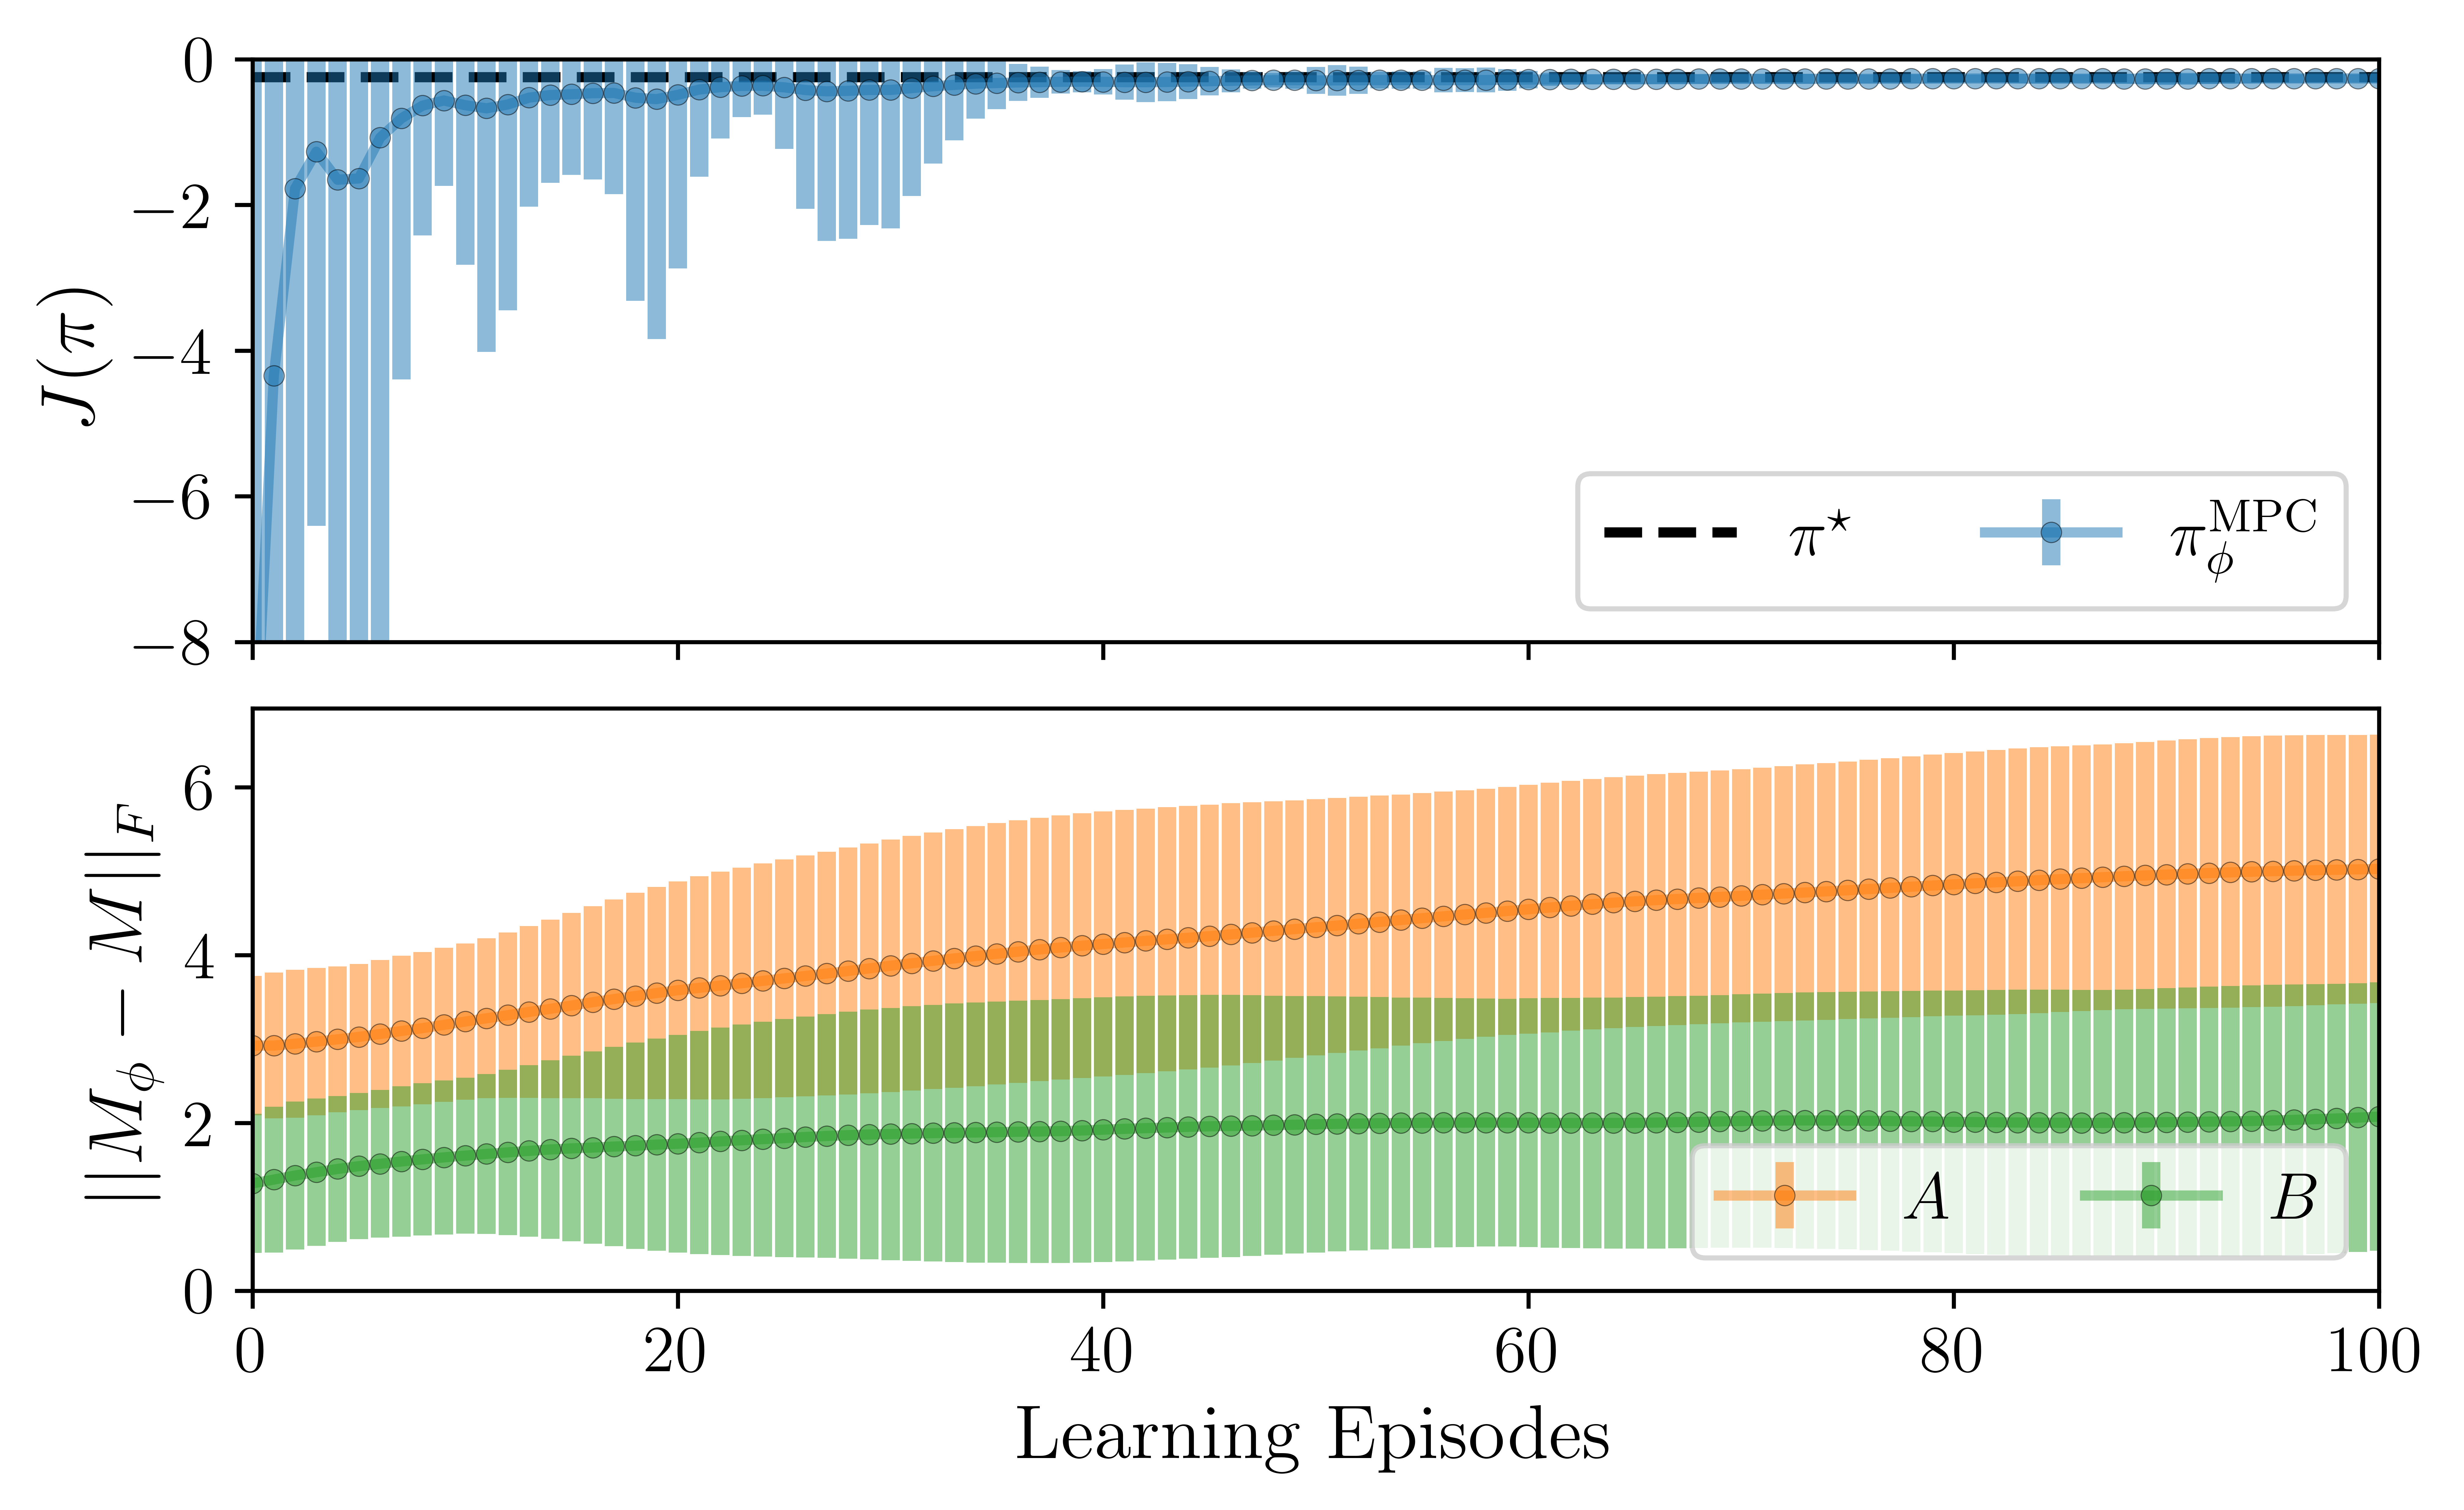

In [13]:
fn = fig_save_dir / 'LQ_J-mismatch'
plot_reg_err(batches, res_avgs, res_errs, mean_frob_A, mean_frob_B, err_frob_A, err_frob_B, opt=opt, fn=fn)